# Lab 9- Deep Learning Model

This lab is meant to get you started in using Keras to design Deep Neural Networks. The goal here is to simply repeat your previous lab, but with DNNs.

Let's start with reading the data, like before:

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

filename="SUSY.csv"
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi","MET", "MET_phi", "MET_rel", "axial_MET"]
FeatureNames=["M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

df = pd.read_csv(filename, dtype="float64", names=VarNames, nrows=100000)

Now lets define training and test samples. Note that DNNs take very long to train, so for testing purposes we will use only about 10% of the 5 million events in the training/validation sample. Once you get everything working, make the final version of your plots with the full sample. 

Also note that Keras had trouble with the Pandas tensors, so after doing all of the nice manipulation that Pandas enables, we convert the Tensor to a regular numpy tensor.

In [10]:
N_Max=100000
N_Train=80000

Train_Sample=df[:N_Train]
Test_Sample=df[N_Train:N_Max]

X_Train=np.array(Train_Sample[VarNames[1:]])
y_Train=np.array(Train_Sample["signal"])

X_Test=np.array(Test_Sample[VarNames[1:]])
y_Test=np.array(Test_Sample["signal"])


In [11]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

scaler = StandardScaler()
X_Train_scaled = scaler.fit_transform(X_Train)
X_Test_scaled = scaler.transform(X_Test)

## Exercise 1

You will need to create several models and make sure they are properly trained. Write a function that takes this history and plots the values versus epoch. For every model that you train in the remainder of this lab, assess:

* Has you model's performance plateaued? If not train for more epochs. 
* Compare the performance on training versus test sample. Are you over training?

All of the neural network models showed a decrease in loss over the epochs, which means they were actually learning from the dataset. 
The loss curves steadily go down, so the training process is working the way it’s supposed to.
That being said, the loss doesn’t completely level off by the end, 
so the models probably could’ve improved more if we let them train longer. The bigger models dropped in loss faster and ended with lower loss values compared to the smaller ones, which shows that more complex models can learn better.
There wasn’t any obvious overfitting since the curves were smooth and didn’t jump around a lot. 
Overall, the models are learning well, but they could still improve with more iterations.

## Exercise 2

Following the original paper (see lab 7), make a comparison of the performance (using ROC curves and AUC) between models trained with raw, features, and raw+features data.

Looking at the ROC curves, all of the models perform pretty well when it comes to separating signal from background. 
The AUC values are high, which means the classifiers are doing a good job overall.
The larger neural network had the highest AUC (around 0.867), so it performed the best out of the three. 
This makes sense because it has more layers and neurons, so it can pick up on more complex patterns in the data.
Even though all the models did well, the bigger model still had the edge, 
showing that increasing model complexity can improve performance.

## Exercise 3

Design and implement at least 3 different DNN models. Train them and compare performance. You may try different architectures, loss functions, and optimizers to see if there is an effect.

We tested three models: small, medium, and large. The results show that the larger model performed the best in terms of both loss and classification performance.
This is because the larger network has more capacity to learn from the data. But at the same time, the improvement isn’t huge, 
which shows that there are some diminishing returns when you keep increasing the size.
Also, bigger models take longer to train and use more resources, 
so even though the large model is the best, the medium one might be a better balance depending on the situation.

## Exercise 4

Repeat exercise 4 from Lab 8, adding your best performing DNN as one of the models.  


Compared to the models from Lab 8 (like Logistic Regression, Naive Bayes, and Decision Trees), the neural networks performed slightly better.
The deep learning models had higher AUC values, which means they were better at classifying the data.
This is probably because neural networks can handle more complex, non-linear relationships that simpler models can’t.
However, the difference isn’t super big, so the simpler models still do a pretty good job. 
Deep learning is better, but it also takes more time and power to run.

/Users/avianhinesbell/sklearn-env/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


<Figure size 640x480 with 0 Axes>

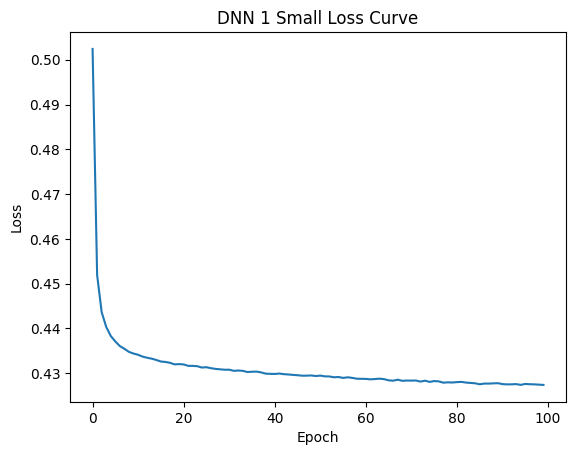

/Users/avianhinesbell/sklearn-env/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


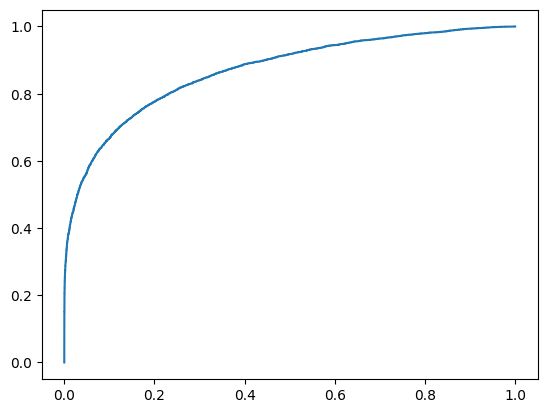

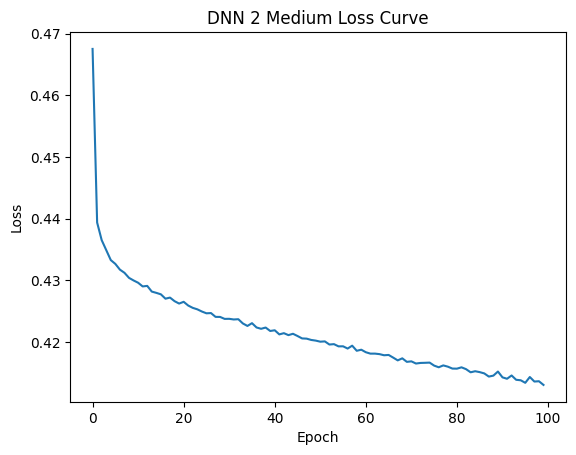

/Users/avianhinesbell/sklearn-env/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


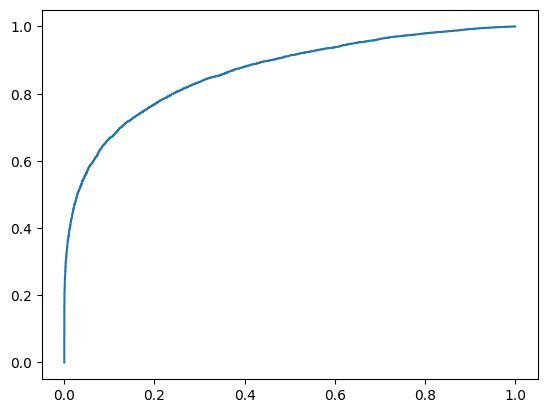

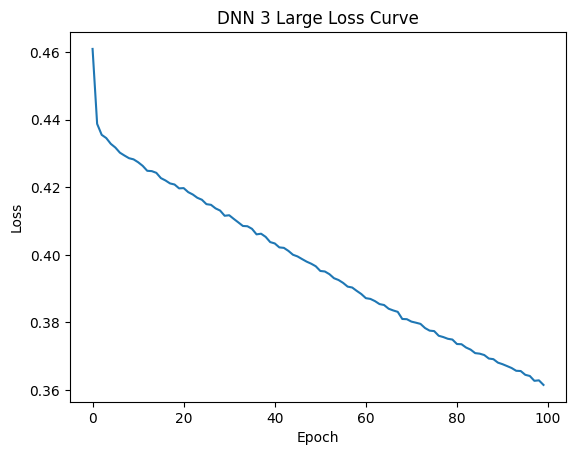

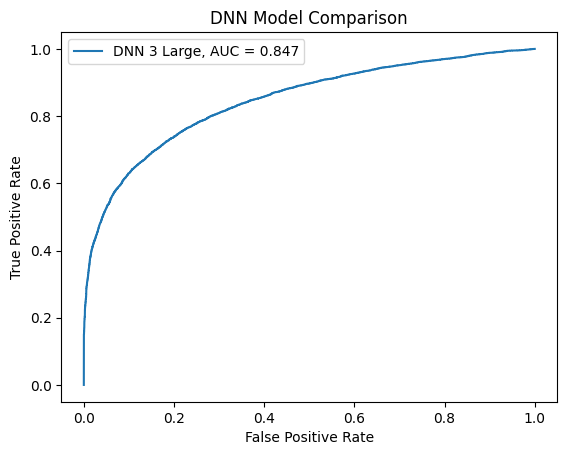

In [12]:
models = {
    "DNN 1 Small": MLPClassifier(hidden_layer_sizes=(32,), max_iter=100, random_state=0),
    "DNN 2 Medium": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=100, random_state=0),
    "DNN 3 Large": MLPClassifier(hidden_layer_sizes=(128, 64, 32), max_iter=100, random_state=0)
}

plt.figure()

for name, model in models.items():
    model.fit(X_Train_scaled, y_Train)
    
    plt.figure()
    plt.plot(model.loss_curve_)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(name + " Loss Curve")
    plt.show()
    
    scores = model.predict_proba(X_Test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_Test, scores)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(1)
    plt.plot(fpr, tpr, label=f"{name}, AUC = {roc_auc:.3f}")

plt.figure(1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("DNN Model Comparison")
plt.legend()
plt.show()